In [1]:
import os, sys, importlib, pathlib
import pandas as pd
from pathlib import Path
sys.path.append (os.path.abspath(".."))

# my utils
from utils import preprocess_listings

LABELS_EN=[
            'open to different cultures', 'cosmopolitan','international view', 'cultural exchange',
            'personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life',
            'meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction',
            'thoughtful service', 'attentive to needs', 'willing to help', 'responsive',
            'fan of Airbnb', 'Airbnb community','love Airbnb', 'travel with Airbnb'
        ]
DICT_FACTOR_ITEMS={"ouverture":['open to different cultures', 'cosmopolitan','international view', 'cultural exchange'],
                   "authenticité":['personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life'],
                   "sociabilité":['meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction'],
                   "auto_promotion":['thoughtful service', 'attentive to needs', 'willing to help', 'responsive'],
                   "exemplarité":['fan of Airbnb', 'Airbnb community','love Airbnb', 'travel with Airbnb']}



x_vars=["host_identity_verified",      
    "review_scores_rating", "has_rating", "number_of_reviews_ltm",#"number_of_reviews_till_Q",
    "host_is_superhost","years_since_host","professional_host", ##'calculated_host_listings_count',
    "host_response_rate","host_response_time",
    # 'status_changed', 'old_host_sp_changed',# "is_changed"
    # "lang", "text_length",
    "has_text", "lang_en","lang_fr","text_length",
    "price","availability_90","room_type", "instant_bookable", #'is_within_1km'
    "ouverture", "authenticité","sociabilité","auto_promotion","exemplarité", 
    "host_picture_type",'pic_no_person','pic_pro_style','pic_life_style',
    "is_smiling","age_class","gender",
    "in_paris",'in_2024'
]  
print(len(x_vars))


31


In [2]:
path_df="../data_processed\listings_tactics_bio_vis-paris_london-2306_2406_ols.csv"
df=pd.read_csv(path_df)
print(df.shape)

C:\Users\yeliu\AppData\Local\Temp\ipykernel_12036\131809557.py:2: DtypeWarning: Columns (68) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(path_df)


(187851, 132)


In [3]:
df.columns.to_list()

['id',
 'listing_url',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'picture_url',
 'host_id',
 'host_url',
 'host_name',
 'host_since',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'calendar_updated',
 'has_availability',
 'availability_30

In [4]:
# df["group"] =df.apply(lambda row: f"{'paris' if row['in_paris'] ==1 else 'london'}_{2024 if row['in_2024'] ==1 else 2023}", axis=1) 
print(df.group.value_counts(dropna=False))

group
paris_2024     62738
london_2024    49856
london_2023    42356
paris_2023     32901
Name: count, dtype: int64


In [ ]:
tactics_bio=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]
tactic_pic=["host_picture_type","is_smiling"]
# vars_person=['age_class','gender']

In [ ]:
# df.to_csv(path_df, index=False)

## desc 2 groups:


In [7]:
## traitement vs control (paris vs london)
importlib.reload(preprocess_listings)
from utils.preprocess_listings import group_mean_table_ttest
 
tactics = [
    "ouverture",
    "authenticité",
    "sociabilité",
    "auto_promotion",
    "exemplarité",
    # "host_picture_type",
    # "is_smiling"
]

vars_ctrl_num=[
    "booking_rate_l90d","review_scores_rating","has_rating","number_of_reviews_ltm",
    "years_since_host",
    "host_response_rate",
    "text_length",
    "price","availability_90","instant_bookable", #'is_within_1km'
    "in_2024"
]
cols_to_check=vars_ctrl_num+tactics

group_mean_table_ttest(df, cols_to_check, group_col='in_paris',        
                    save=False, output_folder="mod_results", filename_noext=None)

[CHECK] ttest takes only 2 groups! OR go to ANOVA!
[INFO] groups :0 vs 1
[INFO] ttest on 187851 lines.

[CHECK] ttest take ONLY numeric cols! 

[WARNING] no numeric cols:
 instant_bookable



in_paris,0,1,ttest_p,significance
proportion,0.490878,0.509122,NaN,NaN
booking_rate_l90d,0.139261,0.12348,0.0,***
review_scores_rating,4.716751,4.751896,0.0,***
has_rating,0.774747,0.734826,0.0,***
number_of_reviews_ltm,8.892075,8.621734,0.00017,***
years_since_host,6.701731,7.038572,0.0,***
host_response_rate,0.842833,0.720017,0.0,***
text_length,33.923969,28.198402,0.0,***
price,218.257157,270.618011,0.0,***
availability_90,48.09913,46.223256,0.0,***


In [ ]:
group_mean_table_ttest(df, cols_to_check, group_col='in_2024',        
                    save=False, output_folder="mod_results", filename_noext=None)

[CHECK] ttest takes only 2 groups! OR go to ANOVA!
[INFO] groups :0 vs 1
[INFO] ttest on 187851 lines.

[CHECK] ttest take ONLY numeric cols! 

[WARNING] no numeric cols:
 instant_bookable



in_2024,0,1,ttest_p,significance
proportion,0.400621,0.599379,NaN,NaN
booking_rate_l90d,0.18498,0.095298,0.0,***
review_scores_rating,4.698738,4.758644,0.0,***
has_rating,0.802636,0.722197,0.0,***
number_of_reviews_ltm,10.032024,7.90051,0.0,***
years_since_host,7.220298,6.641242,0.0,***
host_response_rate,0.813871,0.757869,0.0,***
text_length,34.644126,28.57924,0.0,***
price,235.316954,251.330595,0.0,***
availability_90,42.754056,50.078343,0.0,***


## desc 4 groups vars cat:
EDA = Exploratory Data Analysis

In [7]:
def desc_vars_num(df, vars_num):
    num_list = []
    for col in vars_num:
        temp = (
            df.groupby("group")[col]
            .agg(["mean", "std", "median"])
            .reset_index()
        )
        temp["variable"] = col
        num_list.append(temp)

    df_num_long = pd.concat(num_list, ignore_index=True)

    df_num_wide = df_num_long.pivot_table(
        index="variable",
        columns="group",
        values="mean",
    ).reset_index()
    # df_num_wide

    mean_table = df_num_long.pivot_table(
        index="variable",
        columns="group",
        values="mean"
    )

    std_table = df_num_long.pivot_table(
        index="variable",
        columns="group",
        values="std"
    )


    df_num_wide_std = mean_table.copy()

    for col in mean_table.columns:
        df_num_wide_std[col] = (
            mean_table[col].round(2).astype(str)
            + " (±"
            + std_table[col].round(2).astype(str)
            + ")"
        )

    df_num_wide_std=df_num_wide_std.reset_index()
    return df_num_wide_std


In [8]:
def desc_vars_cat(df, vars_cat):
    df_list = []
    for col in vars_cat:
        temp = (
            df.groupby(["group", col])
            .size()#==count
            .reset_index(name="count")
        )

        # 计算每组总数
        temp["percentage"] = temp["count"] / temp.groupby("group")["count"].transform("sum")

        # 清理
        temp = temp.drop(columns="count")

        temp["variable"] = col
        temp = temp.rename(columns={col: "category"})
            
        df_list.append(temp)

    df_cat_long = pd.concat(df_list, ignore_index=True)


    # ---2 df_wide---
    df_cat_wide = df_cat_long.pivot_table(
        index=["variable", "category"],
        columns="group",
        values="percentage"
    ).reset_index()
    # display(table)
    cols = df_cat_wide.columns[2:]  # 除 variable, category

    # df_cat_wide[cols] = df_cat_wide[cols] * 100
    df_cat_wide[cols] = df_cat_wide[cols].round(2)

    return df_cat_wide


In [11]:
df[vars_ctrl_num].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187851 entries, 0 to 187850
Data columns (total 4 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   host_identity_verified  187851 non-null  object
 1   host_response_time      187851 non-null  object
 2   room_type               187851 non-null  object
 3   instant_bookable        187851 non-null  object
dtypes: object(4)
memory usage: 5.7+ MB


In [13]:
## ctrl
vars_ctrl_cat=[
    # cat
    "host_identity_verified",
    'host_response_time',
    'room_type',
    "instant_bookable"
    
]


vars_ctrl_num=[    
    # num :
    "review_scores_rating", "has_rating", "number_of_reviews_ltm",
    'professional_host',
    "host_response_rate",
    "price","availability_90", 
    
]

# vars_ctrl_num=[x for x in vars_ctrl if pd.api.types.is_any_real_numeric_dtype(df[x])]
# vars_ctrl_cat=[x for x in vars_ctrl if x not in vars_ctrl_num]
print("vars ctrl NUM/CAT: ",len(vars_ctrl_num), len(vars_ctrl_cat))


df_ctrl_num=desc_vars_num(df, vars_num=vars_ctrl_num)
display(df_ctrl_num)
df_ctrl_cat=desc_vars_cat(df, vars_cat=vars_ctrl_cat)
display(df_ctrl_cat)


vars ctrl NUM/CAT:  7 4


group,variable,london_2023,london_2024,paris_2023,paris_2024
0,availability_90,45.54 (±28.53),50.27 (±27.62),39.17 (±27.22),49.92 (±25.13)
1,has_rating,0.78 (±0.42),0.77 (±0.42),0.83 (±0.37),0.68 (±0.47)
2,host_response_rate,0.85 (±0.32),0.84 (±0.34),0.77 (±0.39),0.69 (±0.44)
3,number_of_reviews_ltm,9.22 (±15.95),8.62 (±14.82),11.08 (±18.69),7.33 (±13.9)
4,price,226.77 (±527.16),211.02 (±876.68),246.32 (±570.7),283.36 (±682.86)
5,professional_host,0.61 (±0.49),0.62 (±0.49),0.41 (±0.49),0.34 (±0.48)
6,review_scores_rating,4.7 (±0.49),4.73 (±0.39),4.7 (±0.44),4.78 (±0.31)


group,variable,category,london_2023,london_2024,paris_2023,paris_2024
0,host_identity_verified,f,0.07,0.08,0.07,0.07
1,host_identity_verified,t,0.93,0.92,0.93,0.93
2,host_response_time,a few days or more,0.03,0.04,0.03,0.03
3,host_response_time,no_response_time,0.10,0.10,0.18,0.26
4,host_response_time,within a day,0.11,0.09,0.13,0.10
5,host_response_time,within a few hours,0.18,0.16,0.18,0.15
6,host_response_time,within an hour,0.59,0.62,0.49,0.46
7,instant_bookable,f,0.69,0.67,0.74,0.75
8,instant_bookable,t,0.31,0.33,0.26,0.25
9,room_type,Entire home/apt,0.64,0.66,0.87,0.91


In [ ]:
vars_host_cat=[
    # cat
    'host_is_superhost',
    "age_class","gender",
    "has_text", "lang_en","lang_fr",##???
]
vars_host_num=[
    # num:
    "years_since_host",
    "text_length",
    
    # # tactics
    # "ouverture", "authenticité","sociabilité","auto_promotion","exemplarité", 
    # "host_picture_type",#'pic_no_person','pic_pro_style','pic_life_style',
    # "is_smiling",#"age_class","gender",
    # # "in_paris",'in_2024'

]

print(len(vars_host_cat), len(vars_host_num))


# vars_host_num=[x for x in vars_host if pd.api.types.is_any_real_numeric_dtype(df[x])]
# vars_host_cat=[x for x in vars_host if x not in vars_host_num]
# print("vars host NUM/CAT: ",len(vars_host_num), len(vars_host_cat))

## host
df_host_num=desc_vars_num(df, vars_num=vars_host_num)
display(df_host_num)

df_host_cat=desc_vars_cat(df, vars_cat=vars_host_cat)
display(df_host_cat)

3 2


group,variable,london_2023,london_2024,paris_2023,paris_2024
0,text_length,35.59 (±62.1),32.51 (±58.48),33.42 (±65.45),25.46 (±51.38)
1,years_since_host,7.06 (±3.32),6.4 (±3.68),7.42 (±3.38),6.84 (±3.76)


group,variable,category,london_2023,london_2024,paris_2023,paris_2024
0,age_class,middle,0.37,0.37,0.39,0.39
1,age_class,senior,0.00,0.00,0.01,0.00
2,age_class,unk,0.35,0.37,0.33,0.32
3,age_class,young,0.27,0.25,0.28,0.29
4,gender,Man,0.47,0.44,0.50,0.49
5,gender,Woman,0.16,0.16,0.15,0.16
6,gender,multi,0.03,0.03,0.02,0.02
7,gender,unk,0.35,0.37,0.33,0.32
8,host_is_superhost,0,0.89,0.74,0.81,0.80
9,host_is_superhost,1,0.11,0.26,0.19,0.20


In [99]:
# ---Δ---
#城市变化

# table["Paris-London_2023"] = table["paris_2023"] - table["london_2023"]
# table["Paris-London_2024"] = table["paris_2024"] - table["london_2024"]
# #时间变化
# table["Δ_Paris"] = table["paris_2024"] - table["paris_2023"]
# table["Δ_London"] = table["london_2024"] - table["london_2023"]

# cols = table.columns[2:]  # 除 variable, category

# table[cols] = table[cols] * 100
# table[cols] = table[cols].round(2)
# table

## plot 4 groups

In [278]:
vars_num=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]
# df变成df_long，策略变量位于variable列中
df_long = df.melt(
    id_vars="group",           # 保留 group
    value_vars=vars_tactics,   # 你的策略变量
    var_name="variable",       # 变量名列
    value_name="value"         # 数值列
)
df_long.shape


# 仅用于表格，绘图直接从df_long
# 计算mean和std
df_stats = (
    df_long
    .groupby(["group", "variable"])["value"]
    .agg(mean="mean", std="std")
    .reset_index()
)

## 整理group的顺序
order_groups = ["london_2023", "london_2024", "paris_2023", "paris_2024"]
df_stats["group"] = pd.Categorical(df_stats["group"], categories=order_groups, ordered=True)
display(df_stats)


,group,variable,mean,std
0,london_2023,authenticité,-0.194227,0.759648
1,london_2023,auto_promotion,0.187904,0.785827
2,london_2023,exemplarité,0.019357,0.673041
3,london_2023,ouverture,-0.100366,0.687723
4,london_2023,sociabilité,-0.062065,0.736874
5,london_2024,authenticité,-0.225537,0.764307
6,london_2024,auto_promotion,0.215101,0.760899
7,london_2024,exemplarité,0.028749,0.673578
8,london_2024,ouverture,-0.095423,0.669567
9,london_2024,sociabilité,-0.086375,0.717560


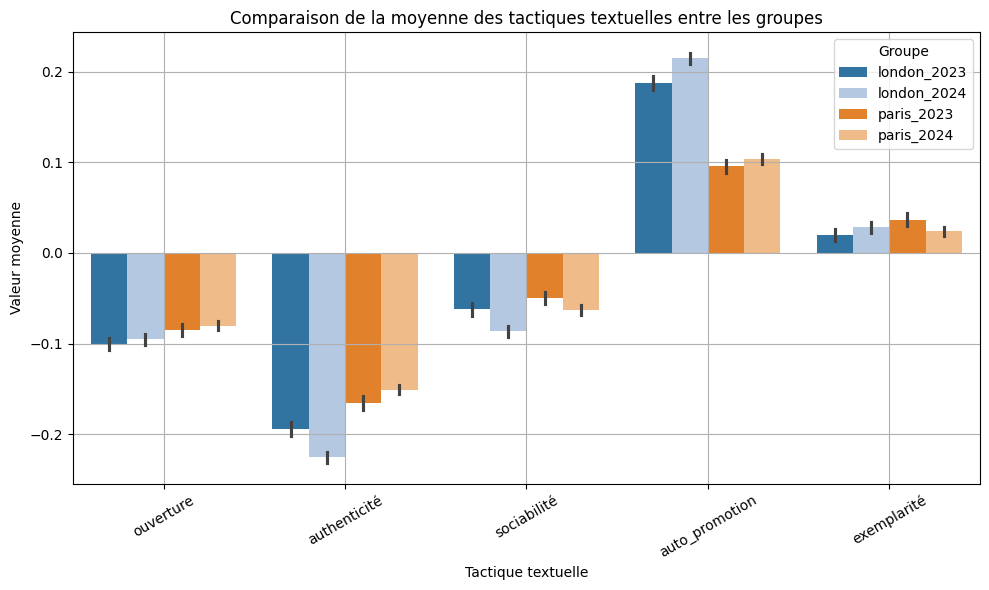

In [280]:
# # vis
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
# palette = {
#     "london_2023": "#9ecae1",   # 浅蓝
#     "london_2024": "#2171b5",   # 深蓝
#     "paris_2023": "#dadaeb",    # 浅紫
#     "paris_2024": "#6a51a3"     # 深紫
# }
groups=df_stats['group'].unique()
colors = sns.color_palette("tab20", len(groups))
palette={k: v for k, v in zip (groups, colors)}


order_tactics = ["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]

sns.barplot(
    data=df_long,   # ⚠️ 用 df_long（不是 df_stats）
    x="variable",
    y="value",
    hue="group",
    palette=palette,
    order=order_tactics,
    # errorbar="sd"
)

plt.xticks(rotation=30)
plt.ylabel("Valeur moyenne")
plt.xlabel("Tactique textuelle")
plt.title("Comparaison de la moyenne des tactiques textuelles entre les groupes")

plt.legend(title="Groupe")
plt.grid()
plt.tight_layout()
plt.show()

In [224]:
vars_pic=["host_picture_type",
          "is_smiling",
        #   "host_is_superhost"
          ]

df_list = []
for col in vars_pic:
    temp = (
        df.groupby(["group", col])#按照group和col,count类别
        .size()
        .reset_index(name="count")
    )
    
    temp['percentage']=temp['count']/temp.groupby('group')['count'].transform('sum')#类别数//该类别总数
    
    temp["variable"] = col
    temp = temp.rename(columns={col: "category"})#统一类别的列名
    # display(temp)
    
    df_list.append(temp)

df_pic = pd.concat(df_list, ignore_index=True)
display(df_pic)
print(df_pic.groupby("variable")["category"].unique())

,group,category,count,percentage,variable
0,london_2023,life_style,13702,0.323496,host_picture_type
1,london_2023,no_person,14682,0.346633,host_picture_type
2,london_2023,pro_style,13972,0.329871,host_picture_type
3,london_2024,life_style,14917,0.299202,host_picture_type
4,london_2024,no_person,18620,0.373476,host_picture_type
5,london_2024,pro_style,16319,0.327323,host_picture_type
6,paris_2023,life_style,9692,0.294581,host_picture_type
7,paris_2023,no_person,10722,0.325887,host_picture_type
8,paris_2023,pro_style,12487,0.379533,host_picture_type
9,paris_2024,life_style,18475,0.294479,host_picture_type


variable
host_picture_type    [life_style, no_person, pro_style]
is_smiling                                   [0.0, 1.0]
Name: category, dtype: object


C:\Users\yeliu\AppData\Local\Temp\ipykernel_9300\2362667210.py:42: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0.9, 0.9, 1])


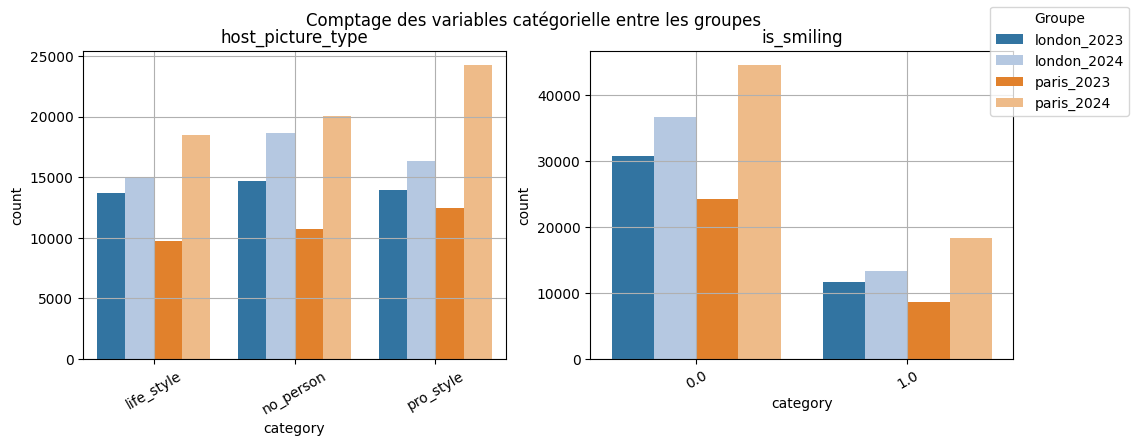

In [281]:

import matplotlib.pyplot as plt
import seaborn as sns
groups=df_pic['group'].unique()
colors = sns.color_palette("tab20", len(groups))
palette={k: v for k, v in zip (groups, colors)}

# palette = {
#     "london_2023": "#9ecae1",
#     "london_2024": "#2171b5",
#     "paris_2023": "#dadaeb",
#     "paris_2024": "#6a51a3"
# }

vars_list = df_pic["variable"].unique()

fig, axes = plt.subplots(nrows=1, ncols=len(vars_list), figsize=(6*len(vars_list),4))

for i, var in enumerate(vars_list):
    ax = axes[i]

    sns.barplot(
        data=df_pic[df_pic["variable"] == var],
        x="category",
        y="count",#"count",# "percentage"
        hue="group",
        palette=palette,
        ax=ax,
    )

    ax.set_title(var)
    ax.set_xlabel("category")
    ax.set_ylabel("count")
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True)
    # 关键：删除每个子图 legend
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# 只保留一个 legend（非常重要）
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title="Groupe", loc="upper right")
plt.tight_layout(rect=[0, 0.9, 0.9, 1])
# plt.tight_layout()
plt.suptitle("Comptage des variables catégorielle entre les groupes")
plt.show()

(93320, 132)
[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765), (0.6823529411764706, 0.7803921568627451, 0.9098039215686274), (1.0, 0.4980392156862745, 0.054901960784313725), (1.0, 0.7333333333333333, 0.47058823529411764)]


C:\Users\yeliu\AppData\Local\Temp\ipykernel_9300\3260503589.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


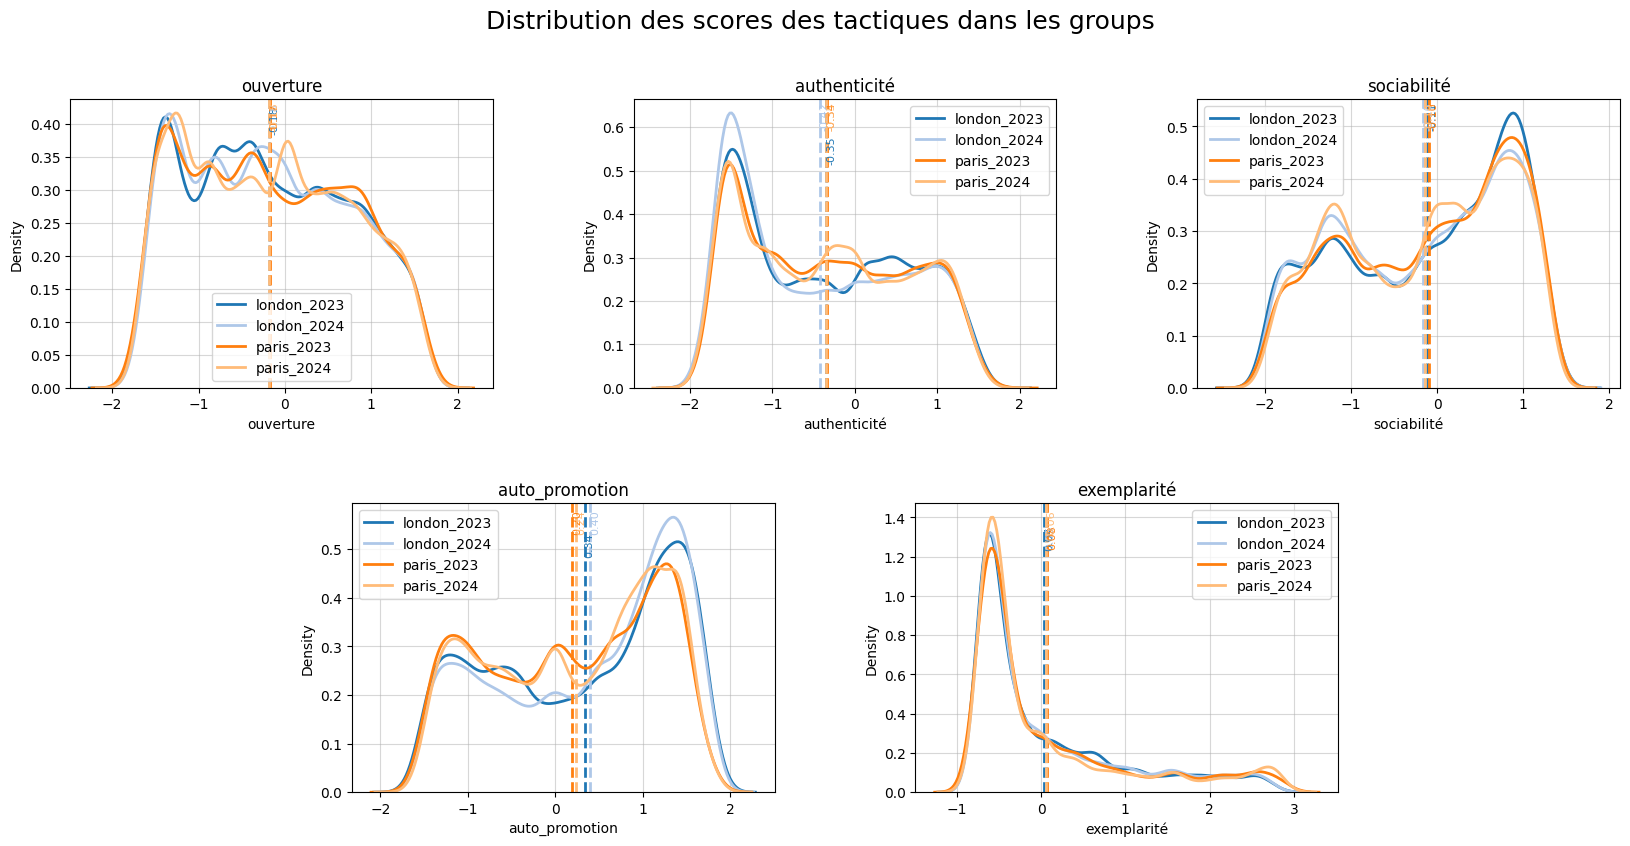

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


df_plot=df[df['has_text']==1]
print(df_plot.shape)

tactics = ["ouverture", "authenticité", "sociabilité", "auto_promotion", "exemplarité"]
groups = df["group"].unique()

colors = sns.color_palette("tab20", len(groups))
# colors = list(palette.values())
print(colors)

# fig, axes = plt.subplots(2, 3, figsize=(15, 8))
# axes = axes.flatten()

## ---subplot layout---
fig = plt.figure(figsize=(20,9))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)
axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])

#------------------------


for i, tactic in enumerate(tactics):
    ax = axes[i]
    
    for group, color in zip(groups, colors):
        group_data = df_plot[df_plot["group"] == group][f"{tactic}"].dropna()
        
        # 填充曲线
        # sns.kdeplot(group_data, fill=True, alpha=0.3, color=color, ax=ax)
        
        # 边界线
        sns.kdeplot(group_data, lw=2, color=color, label=group, ax=ax)
        # mean
        mean_val = group_data.mean()
        ax.axvline(mean_val, linestyle="--", color=color, linewidth=2)
        ax.text(mean_val, ax.get_ylim()[1]*0.9, f"{mean_val:.2f}", 
        color=color, rotation=90, fontsize=8)
        
        
    ax.set_title(tactic)
    ax.legend()
    ax.grid(alpha=0.5)
    
fig.suptitle(
        "Distribution des scores des tactiques dans les groups",
        fontsize=18,
        y=0.98
    )
plt.tight_layout()
plt.show()

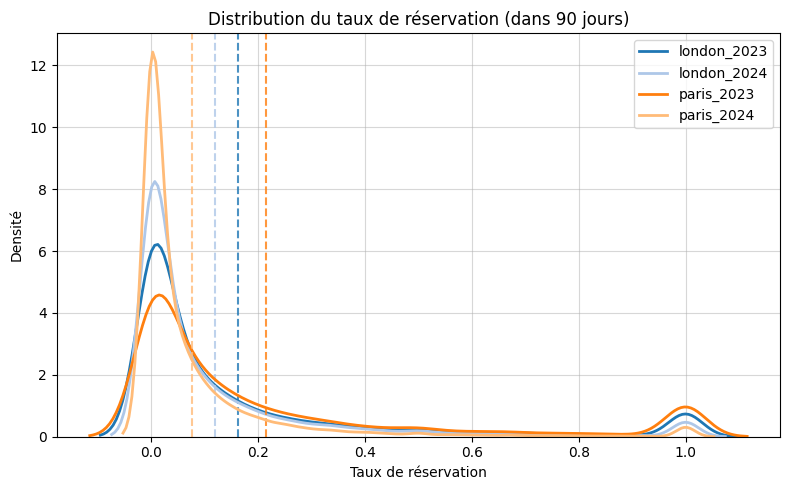

In [275]:

import matplotlib.pyplot as plt
import seaborn as sns

df_plot=df.copy()
fig, ax = plt.subplots(figsize=(8, 5))# 一个图也可以用ax！

for group, color in zip(groups, colors):
    group_data = df_plot[df_plot["group"] == group]["booking_rate_l90d"].dropna()
    
    # KDE 曲线
    sns.kdeplot(group_data, lw=2, color=color, label=group, ax=ax)
    
    # 👉 加均值线（强烈推荐）
    mean_val = group_data.mean()
    ax.axvline(mean_val, linestyle="--", color=color, alpha=0.8)

# 图设置
ax.set_title("Distribution du taux de réservation (dans 90 jours)")
ax.set_xlabel("Taux de réservation")
ax.set_ylabel("Densité")
ax.legend()
ax.grid(alpha=0.5)

plt.tight_layout()
plt.show()

## min max tactiques fr en 


In [238]:
df['has_text'].value_counts(dropna=False)

has_text
0    94531
1    93320
Name: count, dtype: int64

In [246]:
import pandas as pd

tactics = ["ouverture", "authenticité", "sociabilité", "auto_promotion", "exemplarité"]

results = []

# 可选：过滤掉无文本或太短文本
df_clean = df[(df["has_text"]==1) & (df["text_length"] > 10)& (df["text_length"] < 150)].copy()
display(df_clean.shape)

for tactic in tactics:
    score_col = f"{tactic}"   # 如果你用ZSC就换成对应列名
    
    # 分位数
    q_low = df_clean[score_col].quantile(0.05)
    q_high = df_clean[score_col].quantile(0.95)
    
    # 高样本（更典型，不是极端）
    high_pool = df_clean[df_clean[score_col] >= q_high]
    high_sample = high_pool.sample(1)
    high_sample["tactic"] = tactic
    high_sample["level"] = "high"
    
    # 低样本
    low_pool = df_clean[df_clean[score_col] <= q_low]
    low_sample = low_pool.sample(1, random_state=24)
    low_sample["tactic"] = tactic
    low_sample["level"] = "low"
    
    results.append(high_sample)
    results.append(low_sample)

final_samples = pd.concat(results)

# 只保留你关心的列
final_samples = final_samples[["tactic", "level", "host_about", "text_length"] + [f"{t}" for t in tactics]]
final_samples
final_samples.to_csv("tactics_samples-2.csv", index=False)

(73334, 132)

In [244]:
final_samples

,tactic,level,host_about,text_length,ouverture,authenticité,sociabilité,auto_promotion,exemplarité
1373,ouverture,high,Hi! I'm Tijana. I am an IT engineer from Serbi...,120,1.406524,-0.361397,0.881022,1.182195,2.547673
177818,ouverture,low,Je suis ostéopathe exclusive. Je vis dans mon ...,19,-1.760200,0.488800,-1.709205,-0.241269,-0.557330
102599,authenticité,high,I am an Italian photographer living in Paris s...,24,0.819623,1.282933,-0.176734,-0.549233,-0.687558
175030,authenticité,low,Greetings from the Veeve team!\n\n\nVeeve mana...,323,-0.877363,-1.685385,-1.254571,1.411432,-0.526914
123843,sociabilité,high,"Hello, \n\nJe suis Ben et je suis originaire d...",63,1.066608,0.941392,1.280201,-0.154711,-0.135090
130072,sociabilité,low,"Spanish Nurse, settled in Paris for more than ...",19,0.647955,0.809745,-1.629736,-0.659536,-0.741762
27314,auto_promotion,high,"From North London. Like to visit and travel, a...",34,0.513204,0.140607,0.999704,1.626551,-0.034896
33228,auto_promotion,low,I own my Estate Agency known as Link Up Estate...,15,-1.583234,-1.421945,-1.874820,-1.442322,-0.667011
121144,exemplarité,high,Bonjour !\nJe m'appelle Florian et suis un gra...,196,-0.505779,-0.192250,0.124361,1.390772,2.850951
127539,exemplarité,low,"Nous sommes une famille d'architectes, nous ai...",13,1.129275,0.161012,0.447153,-1.202278,-0.788897
